<a href="https://colab.research.google.com/github/ham-codes7/Exploratory-Data-Analysis-/blob/main/Exp_8_22_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n_months = 144
t = np.arange(n_months)


trend = 100 + 2.5 * t


base_seasonal = 20 * np.sin(2 * np.pi * t / 12) + 10 * np.cos(4 * np.pi * t / 12)
amplitude_growth = 1 + 0.4 * (t / n_months)
seasonal = base_seasonal * amplitude_growth


noise = np.random.normal(loc=0.0, scale=8.0, size=n_months)

passengers = trend + seasonal + noise
passengers = np.round(passengers).astype(int)
passengers = np.clip(passengers, a_min=60, a_max=None)

dates = pd.date_range(start='1949-01-01', periods=n_months, freq='MS')

df = pd.DataFrame({'Date': dates, 'Passengers': passengers})
df.head()

,Date,Passengers
0,1949-01-01,114
1,1949-02-01,116
2,1949-03-01,123
3,1949-04-01,130
4,1949-05-01,121


In [9]:
df.shape

(144, 2)

In [10]:
df.dtypes

,0
Date,datetime64[ns]
Passengers,int64


In [11]:
df.head(10)

,Date,Passengers
0,1949-01-01,114
1,1949-02-01,116
2,1949-03-01,123
3,1949-04-01,130
4,1949-05-01,121
5,1949-06-01,126
6,1949-07-01,138
7,1949-08-01,119
8,1949-09-01,93
9,1949-10-01,96


In [12]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df.tail(3)

,Passengers
Date,
1960-10-01,421
1960-11-01,411
1960-12-01,452


In [13]:
df.sample(5, random_state=0)

,Passengers
Date,
1949-08-01,119
1956-06-01,345
1957-02-01,364
1951-03-01,169
1958-03-01,376


In [14]:
# All months in a single year
df.loc['1955']


,Passengers
Date,
1955-01-01,292
1955-02-01,313
1955-03-01,279
1955-04-01,306
1955-05-01,306
1955-06-01,308
1955-07-01,308
1955-08-01,276
1955-09-01,271


In [15]:
# A single month
df.loc['1955-06']

,Passengers
Date,
1955-06-01,308


In [16]:
# A range of months
df.loc['1955-01':'1955-06']

,Passengers
Date,
1955-01-01,292
1955-02-01,313
1955-03-01,279
1955-04-01,306
1955-05-01,306
1955-06-01,308


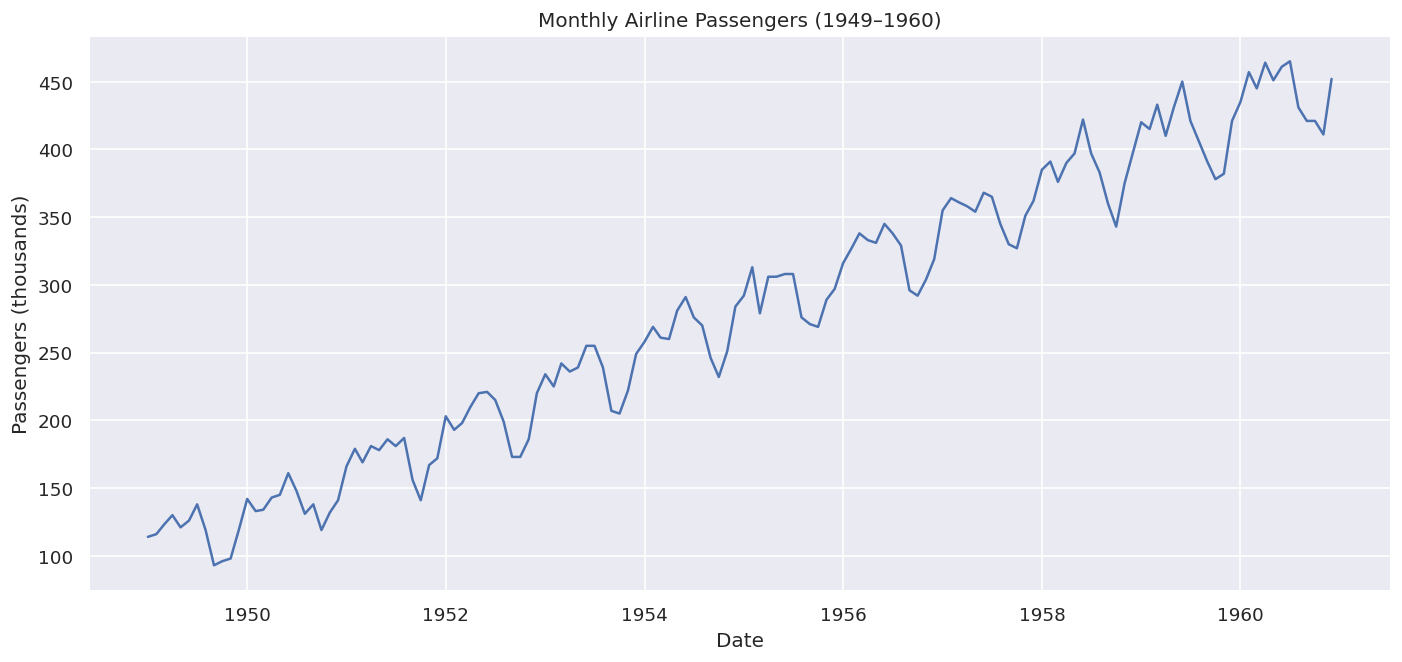

In [17]:
sns.set(rc={'figure.figsize': (14, 6)})
plt.rcParams['figure.dpi'] = 120

g = sns.lineplot(data=df, x=df.index, y='Passengers')
g.set_title("Monthly Airline Passengers (1949–1960)")
g.set_ylabel("Passengers (thousands)")
g.set_xlabel("Date")
plt.show()


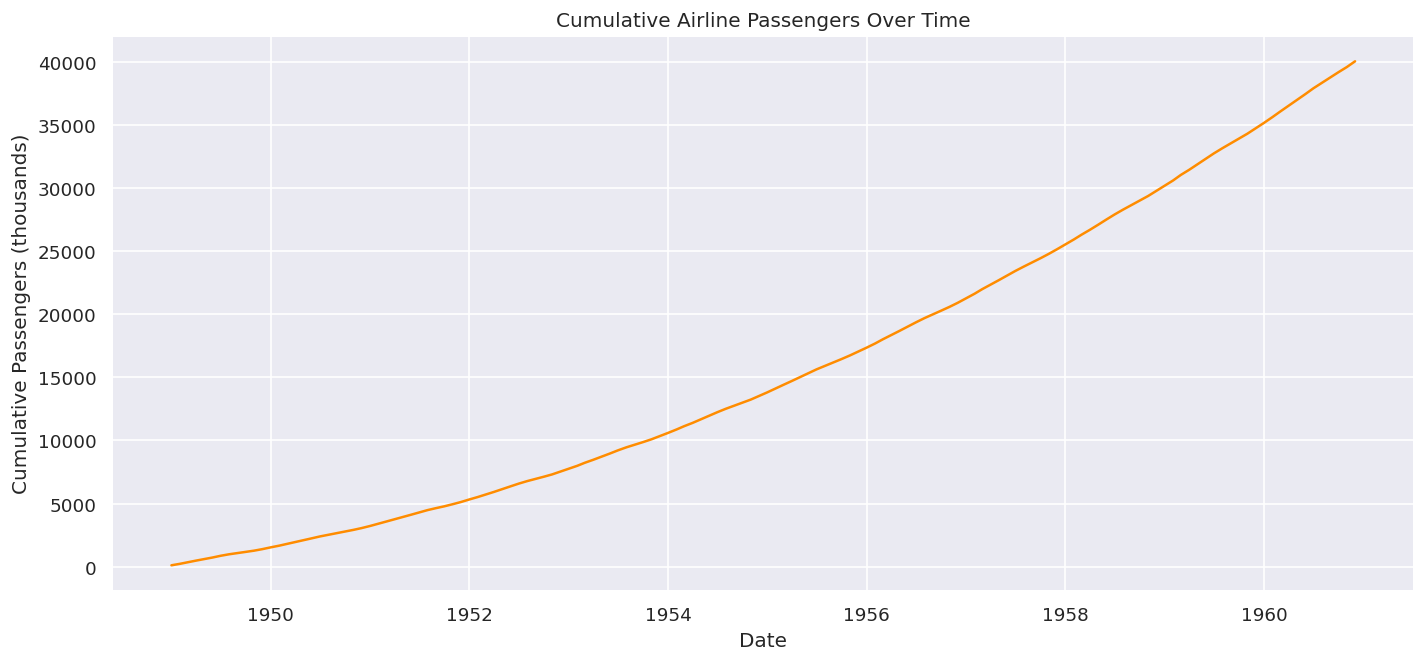

In [18]:
df['Cumulative_Passengers'] = df['Passengers'].cumsum()

plt.figure(figsize=(14, 6))
g = sns.lineplot(data=df, x=df.index, y='Cumulative_Passengers', color='darkorange')
g.set_title("Cumulative Airline Passengers Over Time")
g.set_ylabel("Cumulative Passengers (thousands)")
g.set_xlabel("Date")
plt.show()

In [19]:
# Resample to quarterly mean
quarterly_mean = df[['Passengers']].resample('Q').mean()
quarterly_mean.head()

/tmp/ipykernel_4043/3381218311.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_mean = df[['Passengers']].resample('Q').mean()


,Passengers
Date,
1949-03-31,117.666667
1949-06-30,125.666667
1949-09-30,116.666667
1949-12-31,104.333333
1950-03-31,136.333333


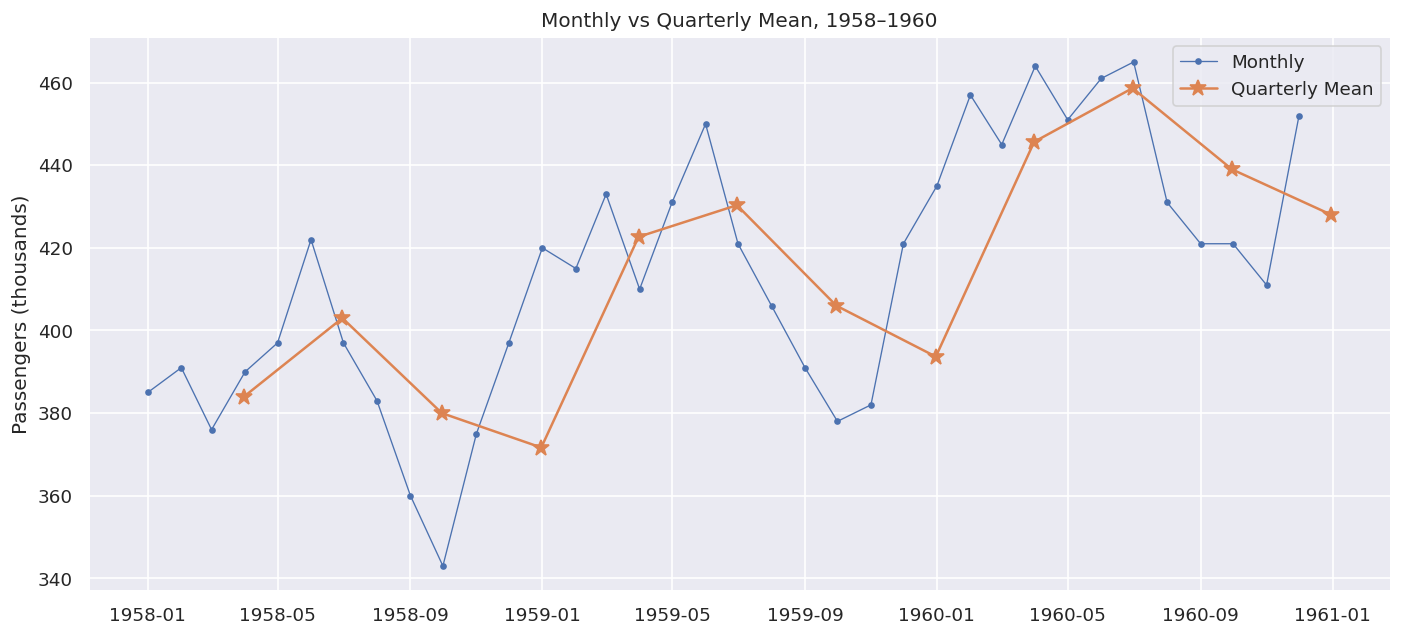

In [20]:
start, end = '1958', '1960'

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.loc[start:end, 'Passengers'], marker='.', linestyle='-', linewidth=0.8, label='Monthly')
ax.plot(quarterly_mean.loc[start:end, 'Passengers'], marker='*', markersize=10, linestyle='-', label='Quarterly Mean')
ax.set_ylabel('Passengers (thousands)')
ax.set_title(f'Monthly vs Quarterly Mean, {start}–{end}')
ax.legend()
plt.show()